<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Predicción del aterrizaje de la primera etapa del Falcon 9 de SpaceX**


## Tarea: Exploración y preparación de datos


Tiempo Estimado Necrsario: **70** minutos


En esta tarea, predeciremos si la primera etapa del Falcon 9 aterrizará con éxito. SpaceX anuncia en su sitio web que los lanzamientos del Falcon 9 tienen un costo de 62 millones de dólares; otros proveedores cobran más de 165 millones de dólares cada uno. Gran parte del ahorro se debe a que SpaceX puede reutilizar la primera etapa.

En este laboratorio, realizarás análisis exploratorio de datos e ingeniería de características.


La primera etapa del Falcon 9 aterrizará con éxito.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Aquí se muestran varios ejemplos de aterrizajes fallidos:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


La mayoría de los aterrizajes fallidos son planificados. SpaceX realiza un aterrizaje controlado en los océanos.


## Objetivos

Realizar análisis exploratorio de datos e ingeniería de características utilizando `Pandas` y `Matplotlib`

* Análisis exploratorio de datos
* Preparación de datos e ingeniería de características

### Importar bibliotecas y definir funciones auxiliares


Importaremos las siguientes bibliotecas al laboratorio.


In [4]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

In [6]:
# pandas es una biblioteca de software escrita para el lenguaje de programación Python para la manipulación y el análisis de datos.
import pandas as pd
#NumPy es una biblioteca para el lenguaje de programación Python, que añade soporte para matrices y arreglos multidimensionales de gran tamaño, junto con una amplia colección de funciones matemáticas de alto nivel para operar con estos arreglos.
import numpy as np
# Matplotlib es una biblioteca de gráficos para Python y pyplot nos proporciona un marco de trabajo para gráficos similar al de MatLab. Usaremos esto en nuestra función de trazado para graficar datos.
import matplotlib.pyplot as plt
#Seaborn es una biblioteca de visualización de datos en Python basada en matplotlib. Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos.
import seaborn as sns

## Análisis exploratorio de datos


Primero, vamos a leer el conjunto de datos de SpaceX en un dataframe de Pandas e imprimir su resumen.


In [7]:
from js import fetch
import io

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp = await fetch(URL)
dataset_part_2_csv = io.BytesIO((await resp.arrayBuffer()).to_py())
df=pd.read_csv(dataset_part_2_csv)
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


Primero, analicemos cómo las variables `FlightNumber` (que indica los intentos de lanzamiento continuos) y `Payload` afectan el resultado del lanzamiento.

Podemos graficar `FlightNumber` frente a `PayloadMass` y superponer el resultado del lanzamiento. Observamos que, a medida que aumenta el número de vuelo, la primera etapa tiene más probabilidades de aterrizar con éxito. La masa de la carga útil también parece ser un factor; incluso con cargas útiles más grandes, la primera etapa suele regresar con éxito.


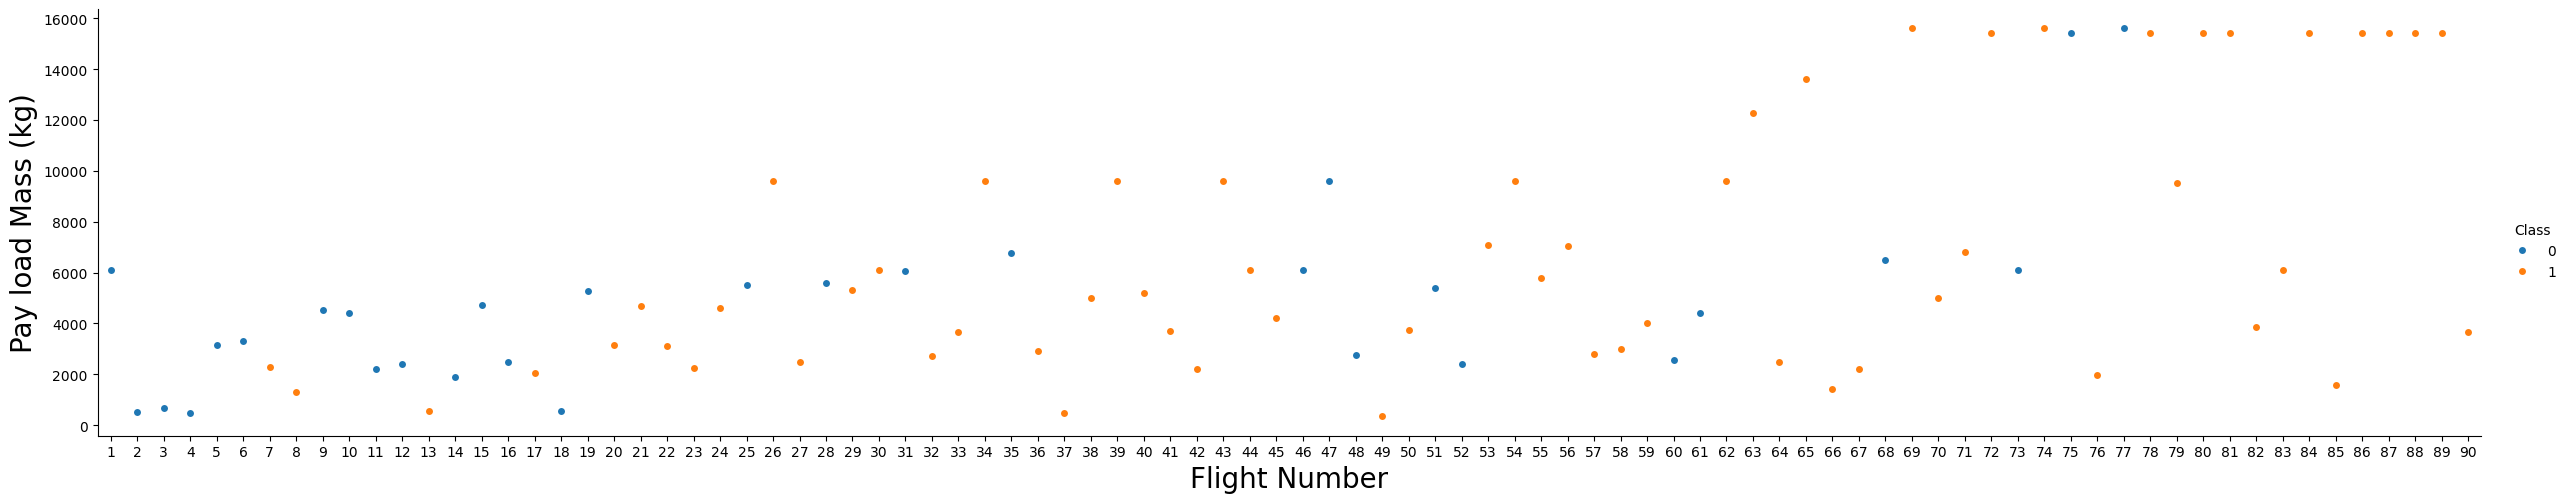

In [8]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

A continuación, vamos a analizar en detalle cada sitio web y visualizar sus registros de lanzamiento.


### TASK 1: Visualice la relación entre el número de vuelo y el lugar de lanzamiento.


Utilice la función <code>catplot</code> para graficar <code>FlightNumber</code> frente a <code>LaunchSite</code>, establezca el parámetro <code>x</code> en <code>FlightNumber</code>, establezca <code>y</code> en <code>Launch Site</code> y establezca el parámetro <code>hue</code> en <code>'class'</code>.


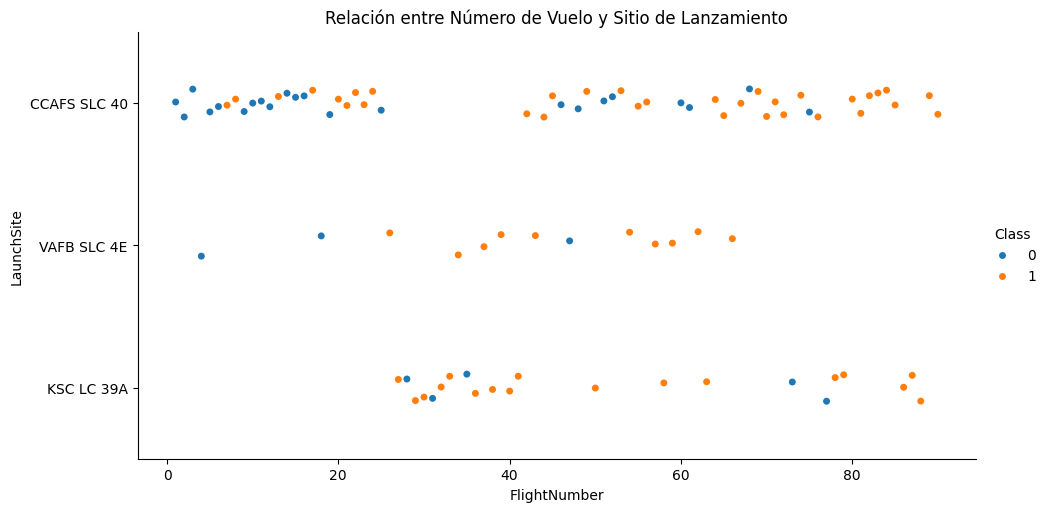

In [9]:
# Grafica un diagrama de dispersión de puntos donde el eje x sea el número de vuelo y el eje y el lugar de lanzamiento, y el tono sea el valor de la clase.
sns.catplot(data=df, x="FlightNumber", y="LaunchSite", hue="Class", aspect=2)

plt.title("Relación entre Número de Vuelo y Sitio de Lanzamiento")
plt.show()

Ahora intenta explicar los patrones que encontraste en los diagramas de dispersión de puntos de Número de Vuelo vs. Lugar de Lanzamiento.


### TASK 2: Visualice la relación entre la masa de la carga útil y el lugar de lanzamiento.


También queremos observar si existe alguna relación entre los lugares de lanzamiento y la masa de su carga útil.


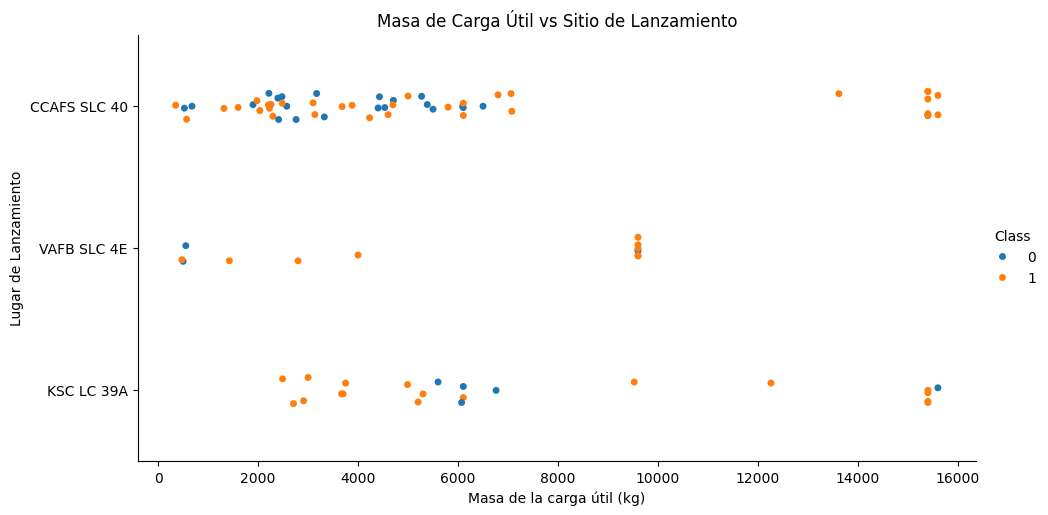

In [10]:
# Grafica un diagrama de dispersión donde el eje x representa la masa de la carga útil (kg), el eje y el lugar de lanzamiento y el color (hue) el valor de la clase.
sns.catplot(data=df, x="PayloadMass", y="LaunchSite", hue="Class", aspect=2)
plt.title("Masa de Carga Útil vs Sitio de Lanzamiento")
plt.xlabel("Masa de la carga útil (kg)")
plt.ylabel("Lugar de Lanzamiento")
plt.show()

Ahora bien, si observas el gráfico de dispersión de masa de carga útil frente al sitio de lanzamiento, encontrarás que para el sitio de lanzamiento VAFB-SLC no se han lanzado cohetes con una masa de carga útil pesada (superior a 10000).


### TASK  3: Visualice la relación entre la tasa de éxito de cada tipo de órbita.


A continuación, queremos comprobar visualmente si existe alguna relación entre la tasa de éxito y el tipo de órbita.


Vamos a crear un gráfico de barras para la tasa de éxito de cada órbita.


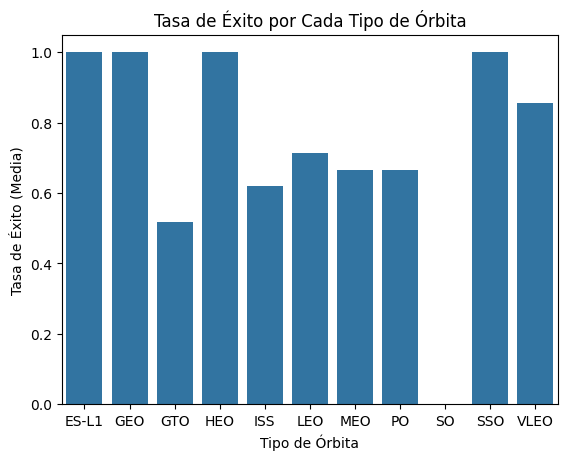

In [11]:
# SUGERENCIA: utilice el método groupby en la columna Orbit y obtenga la media de la columna Class.
# 1. Agrupar por órbita y calcular la media de la columna Class
# Esto nos da la proporción de éxitos (1) frente a intentos totales por órbita.
tasa_exito_orbita = df.groupby('Orbit')['Class'].mean().reset_index()

# 2. Crear el gráfico de barras
sns.barplot(data=tasa_exito_orbita, x='Orbit', y='Class')

# Personalización del gráfico
plt.title('Tasa de Éxito por Cada Tipo de Órbita')
plt.xlabel('Tipo de Órbita')
plt.ylabel('Tasa de Éxito (Media)')
plt.show()

Analice el gráfico de barras para identificar qué órbitas tienen las tasas de éxito más altas.


### TASK  4: Visualice la relación entre el número de vuelo y el tipo de órbita.


Para cada órbita, queremos comprobar si existe alguna relación entre el número de vuelo y el tipo de órbita.


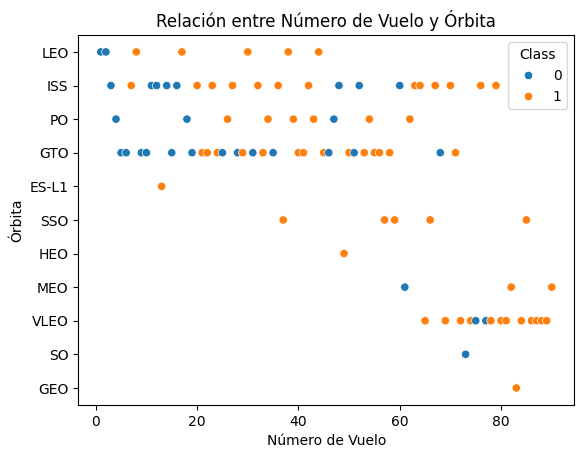

In [12]:
# Grafica un diagrama de dispersión de puntos donde el eje x sea FlightNumber y el eje y sea Orbit, y hue sea el valor de la clase.
# Crear el diagrama de dispersión
sns.scatterplot(data=df, x="FlightNumber", y="Orbit", hue="Class")

# Personalización del gráfico
plt.title("Relación entre Número de Vuelo y Órbita")
plt.xlabel("Número de Vuelo")
plt.ylabel("Órbita")
plt.show()

Se puede observar que, en la órbita LEO, el éxito parece estar relacionado con el número de vuelos. Por el contrario, en la órbita GTO, no parece existir relación entre el número de vuelos y el éxito.


### TASK  5: Visualice la relación entre la masa de la carga útil y el tipo de órbita.


De manera similar, podemos trazar los gráficos de dispersión de masa de carga útil frente a órbita para revelar la relación entre la masa de carga útil y el tipo de órbita.


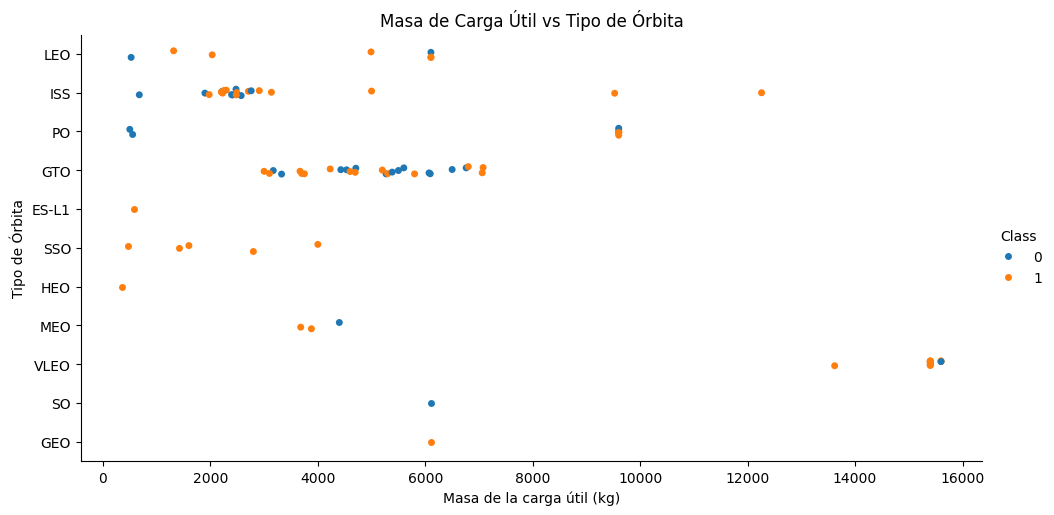

In [13]:
# Grafica un diagrama de dispersión de puntos donde el eje x representa la masa de la carga útil y el eje y la órbita, y el tono representa el valor de la clase.
# Crear el diagrama de dispersión de puntos
sns.catplot(data=df, x="PayloadMass", y="Orbit", hue="Class", aspect=2)

# Personalización de etiquetas
plt.title("Masa de Carga Útil vs Tipo de Órbita")
plt.xlabel("Masa de la carga útil (kg)")
plt.ylabel("Tipo de Órbita")
plt.show()

Con cargas útiles pesadas, la tasa de aterrizajes exitosos o positivos es mayor en órbitas polares, LEO e ISS.

Sin embargo, en GTO, es difícil distinguir entre aterrizajes exitosos y fallidos, ya que ambos resultados se presentan.


### TASK  6: Visualice la tendencia anual de éxito en los lanzamientos


Puedes trazar un gráfico de líneas con el eje x como <code>Año</code> y el eje y como tasa de éxito promedio, para obtener la tendencia promedio de éxito de lanzamiento.


Esta función te ayudará a obtener el año a partir de la fecha:


In [16]:
# Una función para extraer años de la fecha
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year

df['Year'] = Extract_year() 
df['Date'] = year
df.head()
    

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class,Year
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0,2010
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0,2012
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0,2013
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0,2013
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0,2013


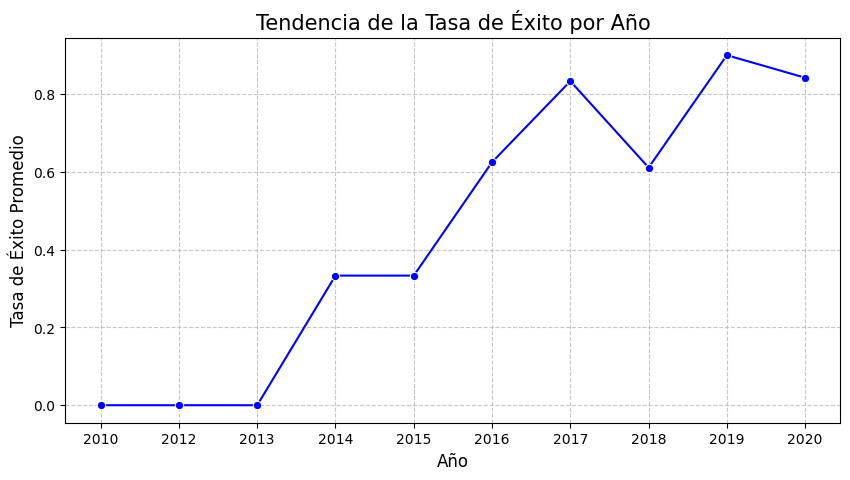

In [17]:
# Traza un gráfico de líneas donde el eje x represente el año extraído y el eje y la tasa de éxito.

# 1. Calculamos la tasa de éxito promedio por año
# (Asegúrate de haber ejecutado la extracción del año antes)
df_yearly_success = df.groupby('Year')['Class'].mean().reset_index()

# 2. Creamos el gráfico de líneas
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_yearly_success, x='Year', y='Class', marker='o', color='b')

# 3. Configuración de etiquetas y título
plt.title('Tendencia de la Tasa de Éxito por Año', fontsize=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Tasa de Éxito Promedio', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7) # Facilita la lectura de los valores
plt.show()

Se puede observar que la tasa de éxito desde 2013 siguió aumentando hasta 2020.


## Ingeniería de características


A estas alturas, ya deberías tener una idea preliminar de cómo cada variable importante afectaría la tasa de éxito; seleccionaremos las características que se utilizarán para la predicción del éxito en el módulo futuro.

In [19]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TASK  7: Cree variables ficticias para las columnas categóricas.


Utilice la función `get_dummies` y el dataframe `features` para aplicar OneHotEncoder a las columnas `Orbits`, `LaunchSite`, `LandingPad` y `Serial`. Asigne el valor a la variable `features_one_hot` y muestre los resultados con el método `head`. El dataframe resultante debe incluir todas las características, incluidas las codificadas.


In [20]:
# SUGERENCIA: Utilice la función get_dummies() en las columnas categóricas.

# 1. Aplicar get_dummies a las columnas especificadas
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])

# 2. Mostrar los primeros resultados
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK  8: Convierta todas las columnas numéricas a `float64`.


Ahora que nuestro dataframe <code>features_one_hot</code> solo contiene números, convierte todo el dataframe al tipo de variable <code>float64</code>.


In [21]:
# SUGERENCIA: utilice la función astype
# Convertir todo el dataframe a float64
features_one_hot = features_one_hot.astype('float64')

# Verificar el cambio de tipos de datos
print(features_one_hot.dtypes)

# Mostrar las primeras filas para confirmar que todo sigue correcto
features_one_hot.head()

FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
                 ...   
Serial_B1056    float64
Serial_B1058    float64
Serial_B1059    float64
Serial_B1060    float64
Serial_B1062    float64
Length: 80, dtype: object


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Ahora podemos exportarlo a un archivo <b>CSV</b> para la siguiente sección, pero para que las respuestas sean consistentes, en el próximo laboratorio proporcionaremos datos en un rango de fechas preseleccionado.


<code>features_one_hot.to_csv('dataset_part\_3.csv', index=False)</code>


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log-->


<!--
| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|
| 2024-07-18        | 1.2     | Anita Verma | Clarified instructions|
-->


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
